In [1]:
## Parte 1 -------------------------------------------------
# 0) Librerías
import io, re
import pandas as pd
import matplotlib.pyplot as plt
import openpyxl
#from google.colab import files


In [11]:
raw = pd.read_excel('tasa_participacion_mujeres.xls', header=None)

In [12]:

# 3) Detectar fila de inicio
date_mask = raw[0].astype(str).str.match(r"^\d{4}/\d{2}$", na=False)
if not date_mask.any():
    #Si la fecha viene como datetime ya; intentamos detectar filas convertibles a periodo
    tmp = pd.to_datetime(raw[0], errors="coerce", format="%Y/%m")
    date_mask = tmp.notna()

if not date_mask.any():
    # Sino, buscar AAAA-MM
    date_mask = raw[0].astype(str).str.match(r"^\d{4}[-]\d{2}$", na=False)

assert date_mask.any(), "No se encontró una fila con fechas tipo '2005/01' o '2005-01' en la primera columna."
start_row = int(date_mask[date_mask].index[0])

# 4) Construir DataFrame limpio (Periodos en col 0 y Valor en col 1)
df = raw.loc[start_row:, [0, 1]].copy()
df.columns = ["Fecha", "Tasa_participacion"]

# 5) Tipos correctos
df["Fecha"] = pd.to_datetime(df["Fecha"].astype(str), format="%Y/%m", errors="coerce")
if df["Fecha"].isna().all():
    df["Fecha"] = pd.to_datetime(df["Fecha"].astype(str), format="%Y-%m", errors="coerce")

df["Tasa_participacion"] = pd.to_numeric(df["Tasa_participacion"], errors="coerce")

In [13]:
df

,Fecha,Tasa_participacion
4,2005-01-01,40.351692
5,2005-02-01,40.432370
6,2005-03-01,41.179709
7,2005-04-01,39.732705
8,2005-05-01,41.027773
...,...,...
253,NaT,NaN
254,NaT,NaN
255,NaT,NaN
256,NaT,NaN


In [14]:

# 6) Limpiar y ordenar
df = (df
      .dropna(subset=["Fecha", "Tasa_participacion"])
      .set_index("Fecha")
      .sort_index())


Periodo detectado: 2005-01 a 2025-09

Resumen estadístico:
count    249.000000
mean      43.472531
std        1.748154
min       34.616667
25%       42.457499
50%       43.366709
75%       44.539689
max       47.135221

Archivo limpio guardado como: tasa_participacion_mujeres_clean.csv


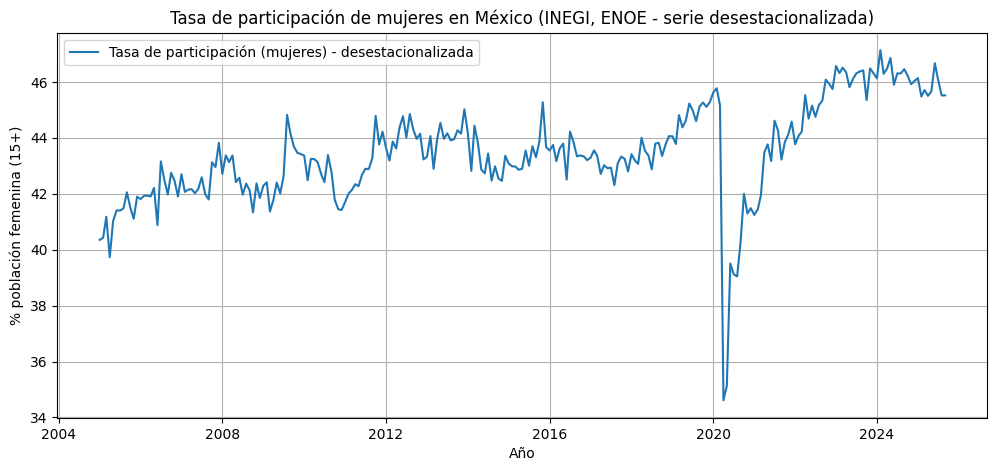

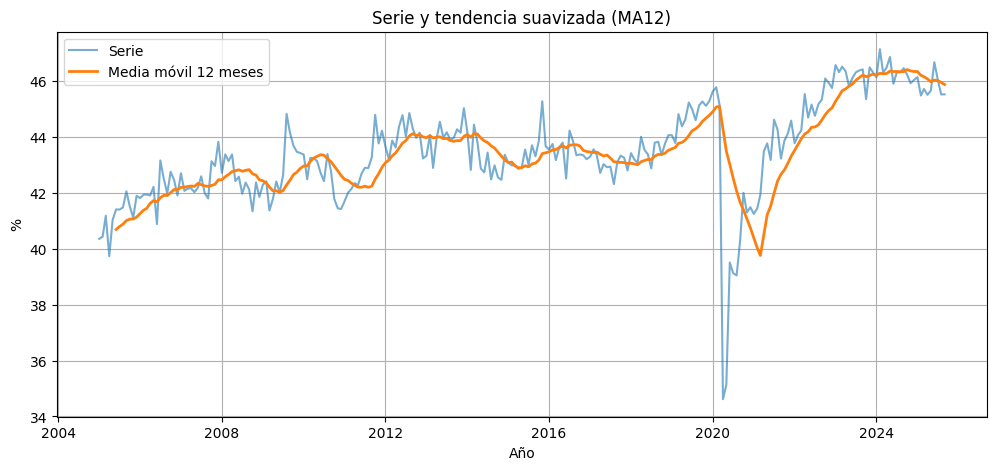

In [15]:


# 7) Reporteen consola
ini, fin = df.index.min(), df.index.max()
print(f"Periodo detectado: {ini.strftime('%Y-%m')} a {fin.strftime('%Y-%m')}")
print("\nResumen estadístico:")
print(df["Tasa_participacion"].describe().to_string())

# 8) Guardar versión limpia
clean_name = "tasa_participacion_mujeres_clean.csv"
df.to_csv(clean_name, encoding="utf-8")
print(f"\nArchivo limpio guardado como: {clean_name}")

# 9) Gráficas
plt.figure(figsize=(12,5))
plt.plot(df["Tasa_participacion"], label="Tasa de participación (mujeres) - desestacionalizada")
plt.title("Tasa de participación de mujeres en México (INEGI, ENOE - serie desestacionalizada)")
plt.xlabel("Año")
plt.ylabel("% población femenina (15+)")
plt.grid(True)
plt.legend()
plt.show()

# 10) Tendencia suavizada con media móvil de 12 meses
df["MA12"] = df["Tasa_participacion"].rolling(window=12, min_periods=6).mean()
plt.figure(figsize=(12,5))
plt.plot(df["Tasa_participacion"], label="Serie", alpha=0.6)
plt.plot(df["MA12"], label="Media móvil 12 meses", linewidth=2)
plt.title("Serie y tendencia suavizada (MA12)")
plt.xlabel("Año")
plt.ylabel("%")
plt.grid(True)
plt.legend()
plt.show()

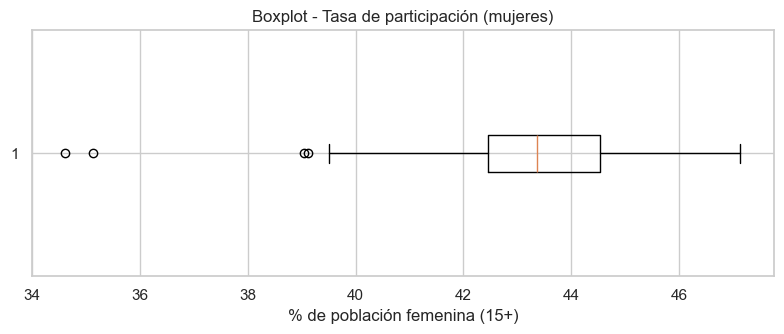

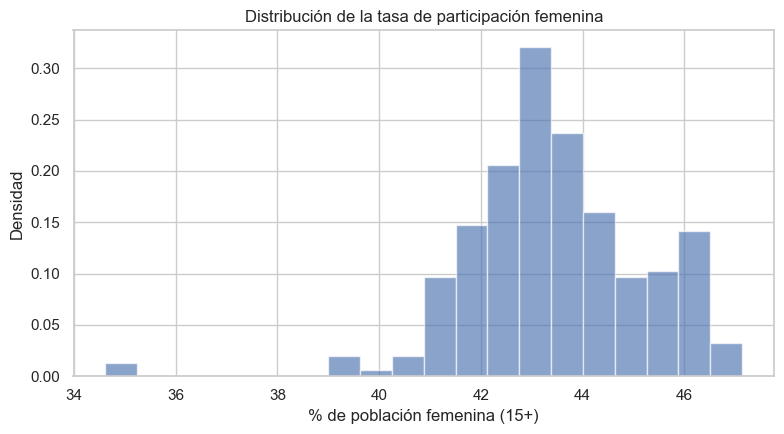

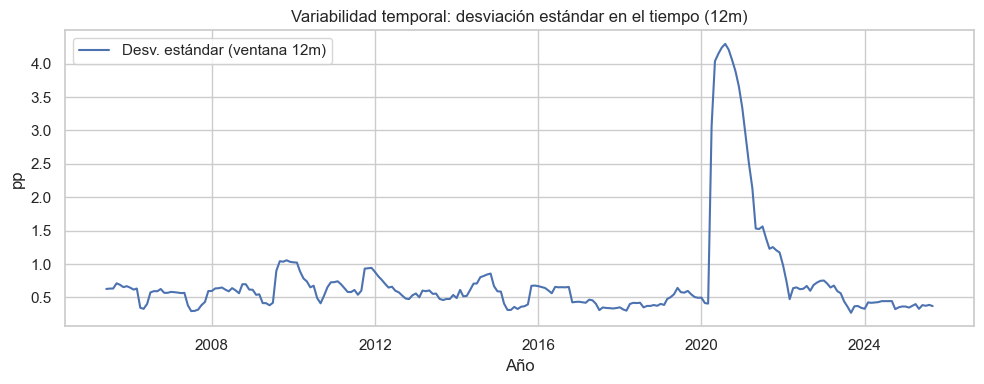

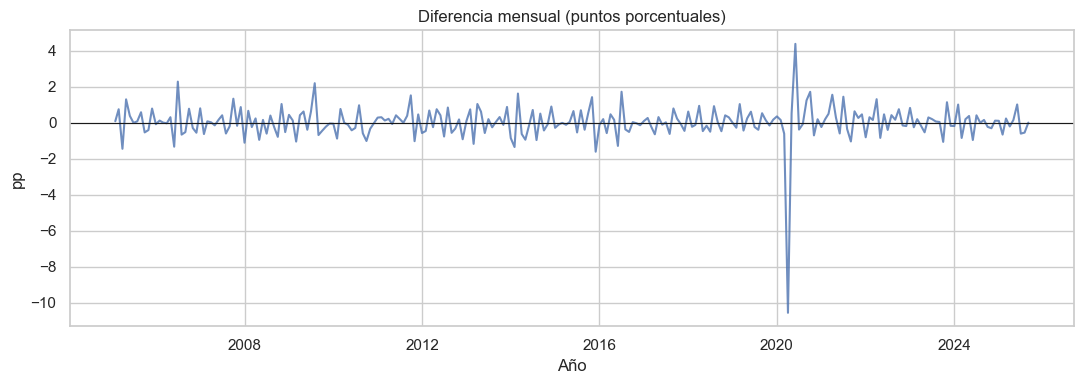

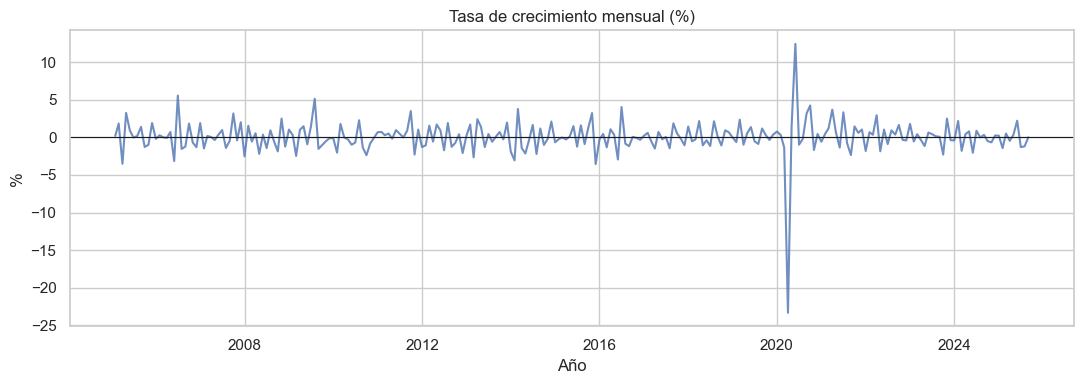

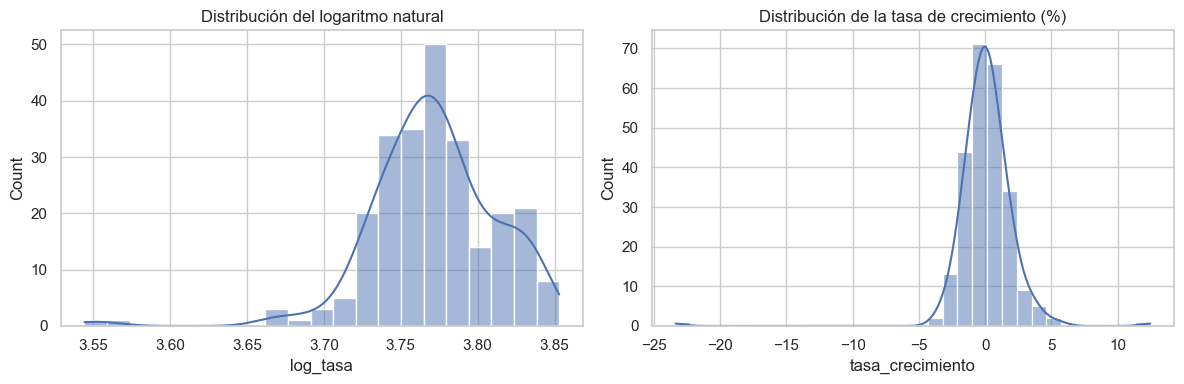


(Sección 2) Estadísticos y exploración

Periodo analizado: 2005-01 – 2025-09  |  Observaciones: 249
Media: 43.47 %, Desv.Est.: 1.75 pp, Min: 34.62 %, Mediana: 43.37 %, Max: 47.14 %
Asimetría (skew): -0.819   |   Curtosis (Fisher): 3.619
Posibles outliers (IQR): 4 observación(es) (ver meses listados abajo).


Meses marcado(s) como posible(s) outlier por IQR:
Fecha
2020-04-01    34.616667
2020-05-01    35.132391
2020-07-01    39.125171
2020-08-01    39.044937


In [17]:
# ===========================
# PARTE 2: Exploración y Transformaciones

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set(style="whitegrid")

# --- 0) Carpeta de salida para figuras
outdir = Path("figs")
outdir.mkdir(exist_ok=True)

# --- 1) Estadísticos descriptivos y forma de la distribución
serie = df['Tasa_participacion'].dropna().copy()
count = serie.shape[0]
mean  = serie.mean()
std   = serie.std()
q1, q2, q3 = serie.quantile([0.25, 0.50, 0.75])
vmin, vmax = serie.min(), serie.max()

# Asimetría y curtosis (Fisher: normal=0)
try:
    from scipy.stats import skew, kurtosis
    skewness = float(skew(serie, nan_policy='omit'))
    kurt_f   = float(kurtosis(serie, nan_policy='omit'))  # Fisher
except Exception:
    skewness = float(serie.skew())       # Pearson
    kurt_f   = float(serie.kurt() - 3)   # aproximación a Fisher

# Detección de posibles outliers por IQR
iqr = q3 - q1
low_fence  = q1 - 1.5 * iqr
high_fence = q3 + 1.5 * iqr
outliers = serie[(serie < low_fence) | (serie > high_fence)]
n_out = outliers.shape[0]

# --- 2) Visualizaciones de la serie
# 2.1 Boxplot
plt.figure(figsize=(8,3.5))
plt.boxplot(serie.values, vert=False, whis=1.5)
plt.title('Boxplot - Tasa de participación (mujeres)')
plt.xlabel('% de población femenina (15+)')
plt.tight_layout()
plt.savefig(outdir / "fig03_boxplot.png", dpi=180)
plt.show()

# 2.2 Histograma (con densidad)
plt.figure(figsize=(8,4.5))
plt.hist(serie.values, bins=20, density=True, alpha=0.65)
plt.title('Distribución de la tasa de participación femenina')
plt.xlabel('% de población femenina (15+)')
plt.ylabel('Densidad')
plt.tight_layout()
plt.savefig(outdir / "fig04_histograma.png", dpi=180)
plt.show()

# 2.3 Desviación estándar en el tiempo
roll_w = 12
roll_std = serie.rolling(roll_w, min_periods=6).std()

plt.figure(figsize=(10,4))
plt.plot(roll_std, label=f'Desv. estándar (ventana {roll_w}m)')
plt.title('Variabilidad temporal: desviación estándar en el tiempo (12m)')
plt.xlabel('Año'); plt.ylabel('pp')
plt.grid(True); plt.legend()
plt.tight_layout()
plt.savefig(outdir / "fig04b_rolling_std.png", dpi=180)
plt.show()

# --- 3) Transformaciones
# 3.1 Logaritmo (no imprescindible en porcentajes)
df['log_tasa'] = np.log(df['Tasa_participacion'])

# 3.2 Diferencia en puntos porcentuales (cambio absoluto mensual)
df['diff_pp'] = df['Tasa_participacion'].diff(1)

# 3.3 Tasa de crecimiento mensual (%) (cambio relativo)
df['crec_%']  = df['Tasa_participacion'].pct_change(1) * 100
df['tasa_crecimiento'] = df['crec_%']  # alias para gráficos

# 3.4 Visualización de transformaciones (series en el tiempo)
plt.figure(figsize=(11,4))
plt.plot(df['diff_pp'], alpha=0.8)
plt.axhline(0, color='k', linewidth=0.8)
plt.title('Diferencia mensual (puntos porcentuales)')
plt.xlabel('Año'); plt.ylabel('pp')
plt.grid(True)
plt.tight_layout()
plt.savefig(outdir / "fig05a_diff_pp.png", dpi=180)
plt.show()

plt.figure(figsize=(11,4))
plt.plot(df['crec_%'], alpha=0.8)
plt.axhline(0, color='k', linewidth=0.8)
plt.title('Tasa de crecimiento mensual (%)')
plt.xlabel('Año'); plt.ylabel('%')
plt.grid(True)
plt.tight_layout()
plt.savefig(outdir / "fig05b_crec_pct.png", dpi=180)
plt.show()

# 3.5 Visualización de transformaciones (distribuciones)
fig, ax = plt.subplots(1,2, figsize=(12,4))
sns.histplot(df['log_tasa'].dropna(), kde=True, ax=ax[0])
ax[0].set_title('Distribución del logaritmo natural')
sns.histplot(df['tasa_crecimiento'].dropna(), kde=True, ax=ax[1])
ax[1].set_title('Distribución de la tasa de crecimiento (%)')
plt.tight_layout()
plt.savefig(outdir / "fig05c_log_hist.png", dpi=180)
plt.savefig(outdir / "fig05d_growth_hist.png", dpi=180)
plt.show()

# --- 4) Resumen para pegar en Word (autollenado)
ini, fin = serie.index.min(), serie.index.max()
txt = f"""
(Sección 2) Estadísticos y exploración

Periodo analizado: {ini.strftime('%Y-%m')} – {fin.strftime('%Y-%m')}  |  Observaciones: {count}
Media: {mean:.2f} %, Desv.Est.: {std:.2f} pp, Min: {vmin:.2f} %, Mediana: {q2:.2f} %, Max: {vmax:.2f} %
Asimetría (skew): {skewness:.3f}   |   Curtosis (Fisher): {kurt_f:.3f}
Posibles outliers (IQR): {n_out} observación(es){' (ver meses listados abajo)' if n_out>0 else ''}.

"""
print(txt)

if n_out > 0:
    print("Meses marcado(s) como posible(s) outlier por IQR:")
    print(outliers.sort_index().to_string())


Prueba Dickey-Fuller Aumentada (ADF) - Serie en niveles
ADF Statistic: -3.132231476947229
p-value: 0.024258055850297087
# Lags Used: 2
# Observations: 246
Critical Value 1%: -3.457215237265747
Critical Value 5%: -2.873361841566324
Critical Value 10%: -2.5730700760129555

Conclusión:  Rechazar H0 (serie estacionaria)


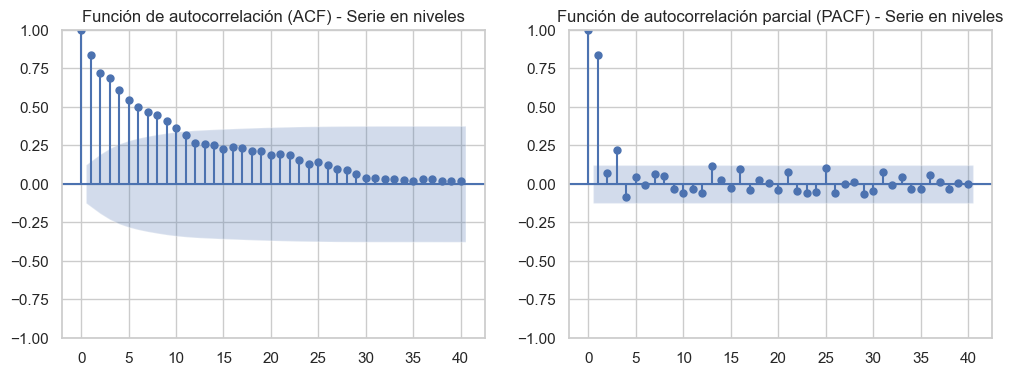


Prueba Dickey-Fuller Aumentada (ADF) - Primera diferencia
ADF Statistic: -15.902705355748825
p-value: 8.293961936443131e-29
# Lags Used: 1
# Observations: 246
Critical Value 1%: -3.457215237265747
Critical Value 5%: -2.873361841566324
Critical Value 10%: -2.5730700760129555

Conclusión:  Rechazar H0 (serie estacionaria)


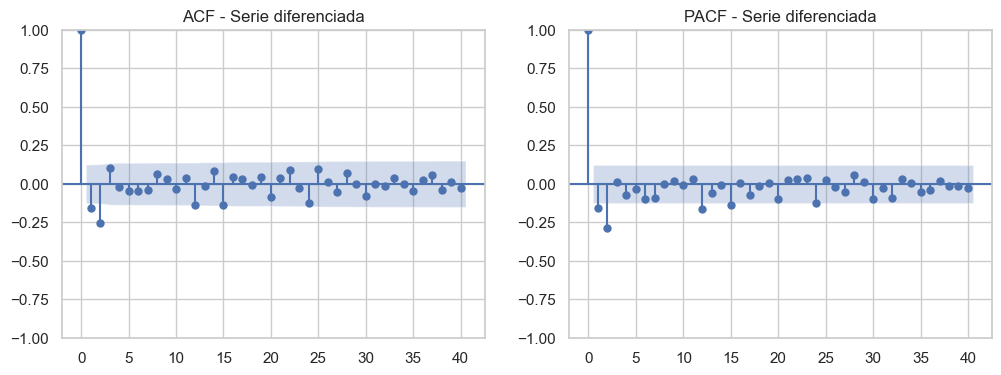

In [18]:
# ===========================
# PARTE 3: Verificación de estacionariedad

from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# 1) Prueba ADF en la serie original
print("Prueba Dickey-Fuller Aumentada (ADF) - Serie en niveles")
result = adfuller(df['Tasa_participacion'].dropna(), autolag='AIC')
labels = ['ADF Statistic', 'p-value', '# Lags Used', '# Observations']
for val, label in zip(result[:4], labels):
    print(f"{label}: {val}")
for key, val in result[4].items():
    print(f"Critical Value {key}: {val}")
print("\nConclusión: ", "Rechazar H0 (serie estacionaria)" if result[1]<0.05 else "No rechazar H0 (serie no estacionaria)")

#  2) ACF y PACF de la serie original
fig, axes = plt.subplots(1,2, figsize=(12,4))
plot_acf(df['Tasa_participacion'].dropna(), lags=40, ax=axes[0])
plot_pacf(df['Tasa_participacion'].dropna(), lags=40, ax=axes[1])
axes[0].set_title('Función de autocorrelación (ACF) - Serie en niveles')
axes[1].set_title('Función de autocorrelación parcial (PACF) - Serie en niveles')
plt.show()

# 3) Prueba ADF sobre la serie diferenciada
df['diff_1'] = df['Tasa_participacion'].diff()
print("\nPrueba Dickey-Fuller Aumentada (ADF) - Primera diferencia")
result_diff = adfuller(df['diff_1'].dropna(), autolag='AIC')
for val, label in zip(result_diff[:4], labels):
    print(f"{label}: {val}")
for key, val in result_diff[4].items():
    print(f"Critical Value {key}: {val}")
print("\nConclusión: ", "Rechazar H0 (serie estacionaria)" if result_diff[1]<0.05 else "No rechazar H0 (serie no estacionaria)")

#  4) ACF y PACF de la serie diferenciada
fig, axes = plt.subplots(1,2, figsize=(12,4))
plot_acf(df['diff_1'].dropna(), lags=40, ax=axes[0])
plot_pacf(df['diff_1'].dropna(), lags=40, ax=axes[1])
axes[0].set_title('ACF - Serie diferenciada')
axes[1].set_title('PACF - Serie diferenciada')
plt.show()


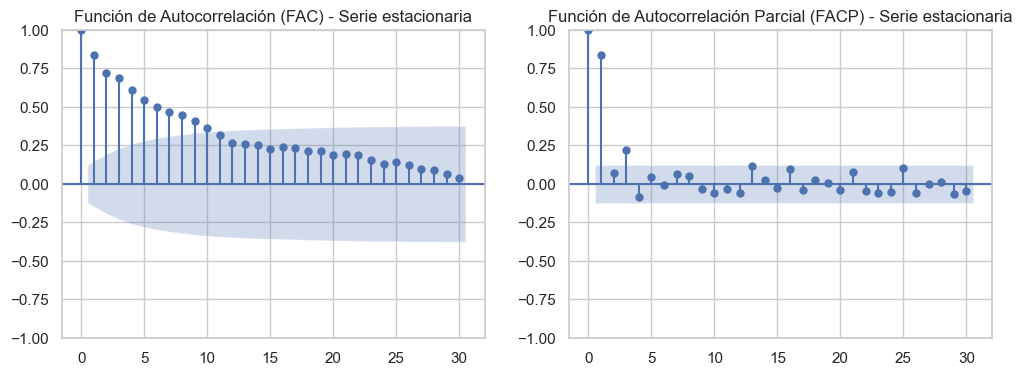

Primeros coeficientes de la FAC:
Lag 0: 1.000
Lag 1: 0.836
Lag 2: 0.720
Lag 3: 0.684
Lag 4: 0.608
Lag 5: 0.546
Lag 6: 0.500
Lag 7: 0.468
Lag 8: 0.449
Lag 9: 0.411
Lag 10: 0.360

Primeros coeficientes de la FACP:
Lag 0: 1.000
Lag 1: 0.839
Lag 2: 0.072
Lag 3: 0.227
Lag 4: -0.086
Lag 5: 0.045
Lag 6: -0.011
Lag 7: 0.070
Lag 8: 0.052
Lag 9: -0.033
Lag 10: -0.062


In [19]:
# ===========================
# PARTE 4: Diagnóstico con FAC y FACP

import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Serie estacionaria (original)
serie = df['Tasa_participacion'].dropna()

# 1) Calcular y graficar FAC y FACP
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(serie, lags=30, ax=axes[0])
plot_pacf(serie, lags=30, ax=axes[1])
axes[0].set_title('Función de Autocorrelación (FAC) - Serie estacionaria')
axes[1].set_title('Función de Autocorrelación Parcial (FACP) - Serie estacionaria')
plt.show()

# 2) Inspeccionar los primeros coeficientes numéricamente
from statsmodels.tsa.stattools import acf, pacf

acf_vals = acf(serie, nlags=10)
pacf_vals = pacf(serie, nlags=10)

print("Primeros coeficientes de la FAC:")
for i, v in enumerate(acf_vals):
    print(f"Lag {i}: {v:.3f}")

print("\nPrimeros coeficientes de la FACP:")
for i, v in enumerate(pacf_vals):
    print(f"Lag {i}: {v:.3f}")
